# Rosenzweig-MacArthur Predator-Prey Model

**Methods:** Analytical equilibria, nullcline and Jacobian stability analysis, RK4 simulation; NumPy, Matplotlib

### Overview
This notebook investigates the equilibrium and stability of the Rosenzweig-MacArthur predator-prey model through analytical calculations and numerical simulations.

---

### Details:

Rosenzweig-MacArthur predator-prey model:

\begin{aligned}
\frac{dN}{dt} &= r_0 N\left(1 - \frac{N}{k}\right) - \frac{c N P}{d + N}, \\

\frac{dP}{dt} &= \frac{\chi c N P}{d + N} - \chi \mu P,
\end{aligned}

where  
- $N(t)$ : prey population  
- $P(t)$ : predator population  
- $r_0$ : intrinsic prey growth rate  
- $k$ : carrying capacity  
- $c$ : capture rate  
- $d$ : half-saturation constant  
- $\chi$ : conversion efficiency  
- $\mu$ : predator mortality rate

### 1. Equilibrium Points

The equilibrium points of the Rosenzweig-MacArthur model are derived analytically to identify the possible steady states of the predator-prey system.

Let $N^*$ and $P^*$ denote the value of $N$ and $P$ where

$$
\frac{dN}{dt} = 0, \qquad \frac{dP}{dt} = 0
$$

#### (1) Predator equation

$$
\frac{dP}{dt} = P\left( \frac{\chi c N}{d+N} - \chi\mu \right) = 0
$$

Thus,

$$
P^* = 0
\quad \text{or} \quad
\frac{cN^*}{d+N^*} = \mu
$$

Solving for $N^*$

$$
cN^* = \mu(d+N^*)
$$

$$
N^* = \frac{\mu d}{c-\mu}
$$

(Requires $c > \mu$.)

---

#### (2) Prey equation

$$
\frac{dN}{dt} = N\left[r_0\left(1-\frac{N}{k}\right) - \frac{cP}{d+N}\right] = 0
$$

Thus,

$$
N^* = 0
\quad \text{or} \quad
r_0\left(1-\frac{N^*}{k}\right) = \frac{cP^*}{d+N^*}
$$

For the coexistence equilibrium, substitute
$$
N^* = \frac{\mu d}{c-\mu}
$$
(from the predator equation) into the prey equation

$$
r_0\left(1-\frac{N^*}{k}\right) = \frac{cP^*}{d+N^*}.
$$

Solving for $P^*$:

$$
P^* = \frac{r_0(d+N^*)}{c}\left(1-\frac{N^*}{k}\right).
$$

---


1. **Extinction equilibrium**

$$
E_0 = (0,0)
$$

This equilibrium comes from both populations are 0.  
Setting $N = 0$ makes $\frac{dN}{dt} = 0$, and setting $P = 0$ makes $\frac{dP}{dt} = 0$.  
Therefore, we get $(0,0)$ as $1^{st}$ equilibruim.

---

2. **Prey-only equilibrium**

$$
E_1 = (k,0)
$$

This equilibrium comes from situation where predator extinction with prey surviving at carrying capacity.  
From the predator equation, setting $P = 0$ gives $\frac{dP}{dt} = 0$.  
Substituting $P = 0$ into the prey equation reduces it to the logistic growth equation
$$
\frac{dN}{dt} = r_0 N\left(1-\frac{N}{k}\right),
$$
which has equilibria at $N = 0$ and $N = k$.  
but $(0, 0)$ already classify as extinction equlibrium; so, solution $N = k$ gives the prey-only equilibrium $(k,0)$.

---

3. **Coexistence equilibrium**

$$
E_2 =
\left(
\frac{\mu d}{c-\mu},
\;
\frac{r_0(d+N^*)}{c}\left(1 - \frac{N^*}{k}\right)
\right)
$$

The coexistence equilibrium occurs when both prey and predator populations exist together.  
From the predator equation with $P \neq 0$, we obtain
$$
N^* = \frac{\mu d}{c-\mu}.
$$
Substituting this value into the prey nullcline,
$$
P = \frac{r_0(d+N)}{c}\left(1-\frac{N}{k}\right),
$$
gives the corresponding equilibrium predator population $P^*$.  
Thus, $E_2$ represents the intersection of the prey and predator nullclines.


Therefore, we can conclude that Rosenzweig-MacArthur model has three equilibrium points.

---

### 2. Nullcline Analysis

The nullclines of the system are analyzed and plotted to examine the conditions for the stability of each equilibrium point.


#### Prey nullcline ($\dot N = 0$)

$$
    N = 0
    \quad \text{or} \quad
    P = \frac{r_0(d+N)}{c}\left(1-\frac{N}{k}\right)
$$

This nullcline consists of the $N$-axis and a downward-opening curve.
Above this curve, $\dot N < 0$; below it, $\dot N > 0$.

---

#### Predator nullcline ($\dot P = 0$)
$$
    P = 0
    \quad \text{or} \quad
    N = \frac{\mu d}{c-\mu}
$$

This nullcline consists of the $P$-axis and a vertical line.
To the right of this line, $\dot P > 0$; to the left, $\dot P < 0$.

---

#### Stability of equilibrium points

1. **Extinction equilibrium** $E_0 = (0,0)$

Near $(0,0)$, prey grows ($\dot N > 0$) while predators decline ($\dot P < 0$).
Therefore, $E_0$ is **unstable**.

---

2. **Prey-only equilibrium** $E_1 = (k,0)$

At $N=k$, prey growth is zero.
If $k < \frac{\mu d}{c-\mu}$, predators cannot invade and $E_1$ is **stable**.
If $k > \frac{\mu d}{c-\mu}$, predators grow and $E_1$ is **unstable**.

---

3. **Coexistence equilibrium**
$$
    E_2 =
    \left(
    \frac{\mu d}{c-\mu},
    \;
    \frac{r_0(d+N^*)}{c}\left(1-\frac{N^*}{k}\right)
    \right)
$$

This point is the intersection of the prey and predator nullclines.
When $N^* < k$, trajectories move toward the intersection from all directions,
so $E_2$ is **locally stable**.

---

#### Importing necessary modules and defining shared parameters

In [66]:
import numpy as np
import matplotlib.pyplot as plt

r0 = 1.0
k = 10.0
c = 1.5
d = 1.0
chi = 0.8
mu = 0.4

N0, P0 = 1.0, 0.5

#### Define the functions of Euler and Runge-Kutta Method

In [67]:
def dNdt(t, N, P):
  return r0*N*(1 - N/k) - c*N*P/(d + N)

def dPdt(t, N, P):
  return chi*c*N*P/(d + N) - chi*mu*P

def rk4(t, N_in, P_in):
  N = np.zeros_like(t)
  P = np.zeros_like(t)
  N[0] = N_in
  P[0] = P_in
  for n in range(len(t)-1):
    h1 = dt*dNdt(t[n], N[n], P[n])
    k1 = dt*dPdt(t[n], N[n], P[n])
    h2 = dt*dNdt(t[n]+dt/2, N[n]+h1/2, P[n]+k1/2)
    k2 = dt*dPdt(t[n]+dt/2, N[n]+h1/2, P[n]+k1/2)
    h3 = dt*dNdt(t[n]+dt/2, N[n]+h2/2, P[n]+k2/2)
    k3 = dt*dPdt(t[n]+dt/2, N[n]+h2/2, P[n]+k2/2)
    h4 = dt*dNdt(t[n]+dt, N[n]+h3, P[n]+k3)
    k4 = dt*dPdt(t[n]+dt, N[n]+h3, P[n]+k3)
    N[n+1] = N[n] + (h1 + 2*h2 + 2*h3 + h4)/6
    P[n+1] = P[n] + (k1 + 2*k2 + 2*k3 + k4)/6
  return t, N, P

#### Solution for numerical methods

##### Set range for `dt` and solutons for each functions

In [68]:
dt = 0.001
t = np.arange(0.0,700.0+dt,dt)
t, N, P = rk4(t, N0, P0)

##### Visualizing Graph for part 2

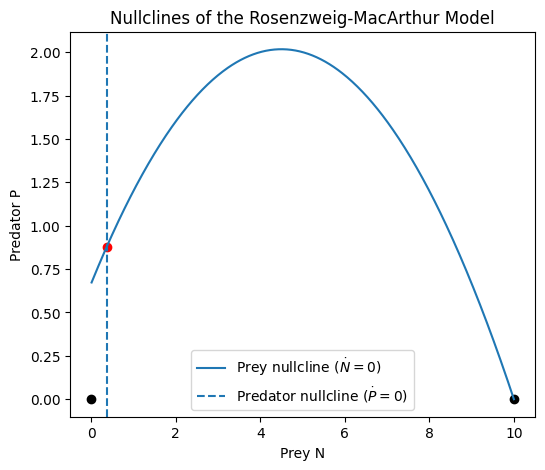

In [ ]:
N = np.linspace(0.01, k, 500)
P_prey = (r0/c)*(1-N/k)*(d+N)

N_star = mu*d/(c-mu)

plt.figure(figsize=(6, 5))

plt.plot(N, P_prey, label="Prey nullcline ($\\dot N = 0$)")
plt.axvline(N_star, linestyle="--", label="Predator nullcline ($\\dot P = 0$)")

plt.scatter(0, 0, color="black")
plt.scatter(k, 0, color="black")
plt.scatter(N_star, (r0/c)*(1-N_star/k)*(d+N_star), color="red")

plt.xlabel("Prey N")
plt.ylabel("Predator P")
plt.legend()
plt.title("Nullclines of the Rosenzweig-MacArthur Model")
plt.show()

This point is the intersection of the prey and predator nullclines.

### 3. Local Stability Analysis

A local stability analysis is performed for each equilibrium point to determine its behavior under small perturbations.

#### Model equations

The Rosenzweig-MacArthur predator-prey model is

$$
\frac{dN}{dt} = r_0 N\left(1-\frac{N}{k}\right) - \frac{c N P}{d+N},
$$

$$
\frac{dP}{dt} = \chi \frac{c N P}{d+N} - \chi \mu P.
$$

Define

$$
f(N,P) = r_0 N\left(1-\frac{N}{k}\right) - \frac{c N P}{d+N},
$$

$$
g(N,P) = \chi \frac{c N P}{d+N} - \chi \mu P.
$$

---

#### Jacobian matrix

Local stability is determined by the Jacobian matrix

$$
J(N,P) =
\begin{pmatrix}
\frac{\partial f}{\partial N} & \frac{\partial f}{\partial P} \\
\frac{\partial g}{\partial N} & \frac{\partial g}{\partial P}
\end{pmatrix}.
$$

The partial derivatives are

$$
\frac{\partial f}{\partial N}
= r_0\left(1-\frac{2N}{k}\right)
- \frac{c P d}{(d+N)^2},
$$

$$
\frac{\partial f}{\partial P}
= -\frac{c N}{d+N},
$$

$$
\frac{\partial g}{\partial N}
= \chi \frac{c P d}{(d+N)^2},
$$

$$
\frac{\partial g}{\partial P}
= \chi\left(\frac{c N}{d+N} - \mu\right).
$$

---

The system has three equilibrium points.

#### 1. Extinction equilibrium

$$
E_0 = (0,0)
$$

Evaluating the Jacobian at $E_0$ gives

$$
J(E_0) =
\begin{pmatrix}
r_0 & 0 \\
0 & -\chi\mu
\end{pmatrix}.
$$

The eigenvalues are

$$
\lambda_1 = r_0 > 0, \qquad \lambda_2 = -\chi\mu < 0.
$$

Since one eigenvalue is positive and the other is negative,  
the extinction equilibrium $E_0$ is a **saddle point** and is **always unstable**.

---

#### 2. Prey-only equilibrium

$$
E_1 = (k,0)
$$

Evaluating the Jacobian at $E_1$ gives

$$
J(E_1) =
\begin{pmatrix}
- r_0 & -\frac{c k}{d+k} \\
0 & \chi\left(\frac{c k}{d+k} - \mu\right)
\end{pmatrix}.
$$

The eigenvalues are

$$
\lambda_1 = -r_0 < 0,
$$

$$
\lambda_2 = \chi\left(\frac{c k}{d+k} - \mu\right).
$$

Therefore:

- $E_1$ is **locally stable** if
$$
\frac{c k}{d+k} < \mu,
$$

- $E_1$ is **unstable** if
$$
\frac{c k}{d+k} > \mu.
$$

This condition means predators cannot invade if prey density is insufficient to overcome predator mortality.

---

#### 3. Coexistence equilibrium

The coexistence equilibrium satisfies

$$
N^* = \frac{\mu d}{c-\mu}, \qquad c > \mu,
$$

$$
P^* = \frac{r_0(d+N^*)}{c}\left(1-\frac{N^*}{k}\right).
$$

At this equilibrium,

$$
\frac{c N^*}{d+N^*} = \mu.
$$

Substituting into the Jacobian gives

$$
J(E_2) =
\begin{pmatrix}
r_0\left(1-\frac{2N^*}{k}\right)
- \frac{c P^* d}{(d+N^*)^2}
&
-\mu
\\
\chi \frac{c P^* d}{(d+N^*)^2}
&
0
\end{pmatrix}.
$$

---

#### Stability conditions for the coexistence equilibrium

The trace of the Jacobian is

$$
\text{Tr}(J) =
r_0\left(1-\frac{2N^*}{k}\right)
- \frac{c P^* d}{(d+N^*)^2},
$$

and the determinant is

$$
\det(J) =
\chi \mu \frac{c P^* d}{(d+N^*)^2} > 0.
$$

Thus:

- The coexistence equilibrium $E_2$ is **locally asymptotically stable** if
$$
\text{Tr}(J) < 0,
$$

- It is **unstable** if
$$
\text{Tr}(J) > 0.
$$

---

#### Summary of stability results

- $E_0 = (0,0)$: saddle point, always unstable  
- $E_1 = (k,0)$: stable if $\frac{c k}{d+k} < \mu$  
- $E_2 = (N^*,P^*)$: stable if $\text{Tr}(J) < 0$

These results explain the long-term behavior observed in the nullcline and phase-plane plots.


#### Classification of the coexistence equilibrium $E_2$

Specifically for case of $E_2$, the Jacobian matrix at the coexistence equilibrium
$E_2 = (N^*, P^*)$ has

$$
\text{Tr}(J)
= r_0\left(1-\frac{2N^*}{k}\right)
- \frac{c P^* d}{(d+N^*)^2},
$$

$$
\det(J)
= \chi \mu \frac{c P^* d}{(d+N^*)^2} > 0.
$$

Because $\det(J) > 0$, the coexistence equilibrium cannot be a saddle point.
Its stability type is determined by the sign of $\text{Tr}(J)$ and by comparing
$\text{Tr}(J)^2 [\tau^2]$ with $4\det(J) [4\delta]$.

---

#### Eigenvalue classification criteria

For a two-dimensional system:

- If $\text{Tr}(J) < 0$ and $\det(J) > 0$, the equilibrium is **stable**
- If $\text{Tr}(J) > 0$ and $\det(J) > 0$, the equilibrium is **unstable**

More precisely:

- **Stable node** if
$$
\text{Tr}(J) < 0
\quad \text{and} \quad
\text{Tr}(J)^2 > 4\det(J)
$$

- **Stable spiral (focus)** if
$$
\text{Tr}(J) < 0
\quad \text{and} \quad
\text{Tr}(J)^2 < 4\det(J)
$$

- **Unstable node** if
$$
\text{Tr}(J) > 0
\quad \text{and} \quad
\text{Tr}(J)^2 > 4\det(J)
$$

- **Unstable spiral (focus)** if
$$
\text{Tr}(J) > 0
\quad \text{and} \quad
\text{Tr}(J)^2 < 4\det(J)
$$

---

#### Interpretation for the Rosenzweig-MacArthur model

For the coexistence equilibrium $E_2$:

- Since $\det(J) > 0$, trajectories near $E_2$ either spiral or move directly
toward or away from the equilibrium.
- If $\text{Tr}(J) < 0$, predator and prey populations return to equilibrium
after small perturbations.
- If $\text{Tr}(J) > 0$, small perturbations grow and the equilibrium becomes
unstable.

In ecological terms:

- **Stable node**: populations return monotonically to equilibrium
- **Stable spiral**: populations exhibit damped oscillations
- **Unstable spiral**: populations exhibit growing oscillations
- **Unstable node**: populations diverge without oscillations

---


### 4. Numerical Simulation

Numerical simulations are performed in Python to examine the behavior of the system and compare the results with the analytical stability analysis computed in `3. Local Stability Analysis` above.

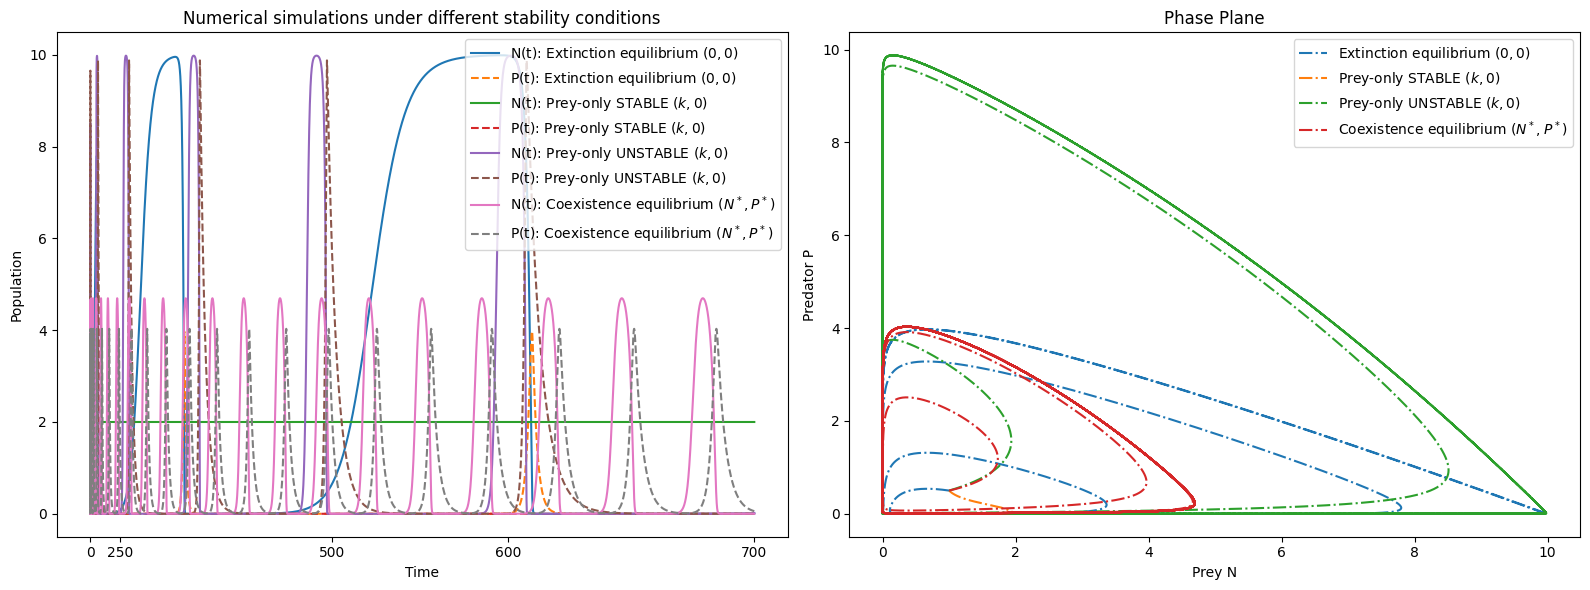

In [ ]:
cases = [
  {
    "label": "Extinction equilibrium $(0,0)$",
    "params": dict(r0=0.1, k=10.0, c=1.5, d=1.0, chi=0.8, mu=0.6)
  },
  {
    # ck/(d+k) < mu  -> predator cannot invade -> STABLE
    "label": "Prey-only STABLE $(k,0)$",
    "params": dict(r0=1.0, k=2.0, c=1.5, d=1.0, chi=0.8, mu=1.2)
  },
  {
    # ck/(d+k) > mu -> predator invades -> UNSTABLE
    "label": "Prey-only UNSTABLE $(k,0)$",
    "params": dict(r0=1.0, k=10.0, c=1.5, d=1.0, chi=0.8, mu=0.2)
  },
  {
    "label": "Coexistence equilibrium $(N^*,P^*)$",
    "params": dict(r0=1.0, k=5.0, c=1.5, d=1.0, chi=0.8, mu=0.4)
  }
]


fig, ax = plt.subplots(1, 2, figsize=(16, 6))

for case in cases:
  r0  = case["params"]["r0"]
  k   = case["params"]["k"]
  c   = case["params"]["c"]
  d   = case["params"]["d"]
  chi = case["params"]["chi"]
  mu  = case["params"]["mu"]

  t, N, P = rk4(t, N0, P0)

  ax[0].plot(t, N, label=f"N(t): {case['label']}")
  ax[0].plot(t, P, linestyle="--", label=f"P(t): {case['label']}")
  ax[1].plot(N, P, linestyle="-.", label=case["label"])

ax[0].set_xlabel("Time")

def forward(x):
    return x**3

def inverse(x):
    return np.cbrt(x)

ax[0].set_xscale('function', functions=(forward, inverse))
ax[0].set_xticks([0,250, 500, 600, 700])

ax[0].set_ylabel("Population")
ax[0].set_title("Numerical simulations under different stability conditions")
ax[0].legend(fontsize=8)
ax[0].legend(loc="upper right")

ax[1].set_xlabel("Prey N")
ax[1].set_ylabel("Predator P")
ax[1].set_title("Phase Plane")
ax[1].legend()

plt.tight_layout()
plt.show()


---

### Discussion

The figure above shows numerical simulations of the Rosenzweig-MacArthur predator-prey model under different stability conditions. The simulations are used to confirm the analytical results obtained from the nullcline and Jacobian analyses.

For the extinction equilibrium $(0,0)$, the time series and phase-plane plots show that trajectories move away from the origin. Even when the initial condition is close to zero, the prey population increases while the predator population does not persist. This confirms that the extinction equilibrium is unstable, which agrees with the Jacobian analysis where one eigenvalue is positive.

For the prey-only equilibrium $(k,0)$, two different cases are considered. When $\frac{ck}{d+k} < \mu$, predator populations decay to zero and the prey population converges to the carrying capacity $k$. The phase-plane trajectories approach $(k,0)$, showing that predators cannot invade. This confirms that the prey-only equilibrium is stable under this condition. In contrast, when $\frac{ck}{d+k} > \mu$, predators successfully invade the system. The predator population increases from low density and the trajectory moves away from $(k,0)$, which shows that the prey-only equilibrium becomes unstable. These results agree with the invasion condition derived from the nullcline and Jacobian analyses.

For the coexistence equilibrium $(N^*, P^*)$, the simulations show oscillatory behavior in both prey and predator populations that gradually decreases over time. In the phase plane, trajectories spiral toward a positive equilibrium point. This indicates that the coexistence equilibrium is locally asymptotically stable, consistent with the Jacobian analysis where the trace is negative and the determinant is positive.